# Terra Audit — AWD vs PTR Random Forest (research reproduction)

This notebook reproduces, step by step, the **experimental Random Forest model** shown on Terra Audit's
**AWD Validation** tab. It uses the same real research dataset, the same features, the same preprocessing,
the same random seeds and the same model settings as the deployed model.

> **What this model predicts — please read first**
>
> * It labels a whole rice season as **AWD-like** or **PTR-like** (PTR = *puddled transplanted rice*,
>   the conventional practice the research uses as its comparison class).
> * It is **not** a count of AWD drying events and **not** an independent verification of AWD cycles.
> * The released research data contains **no measured continuous-flooding (CF) labels** — PTR is a sowing
>   method used as the conventional-flooding comparison, not a CF measurement.
> * It was trained on **Punjab, India (Kharif 2024)**. Its accuracy on Bangladesh fields is **unknown**.
> * Terra Audit's drydown counting and carbon calculations do **not** use this model.

**How to run:** in Google Colab choose **Runtime → Run all**. No Terra Audit backend, database or
Google Earth Engine account is needed — the notebook downloads the public research data itself.


## 1. Install dependencies

We pin **scikit-learn 1.9.1**, the exact version Terra Audit used to train and save the deployed model,
so the results can be compared one-to-one. `pyarrow` reads the research `.parquet` files.


In [1]:
%pip install -q scikit-learn==1.9.1 pyarrow pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.7 MB/s eta 0:00:00


## 2. Imports, seeds and fixed settings

Every random choice uses a fixed seed (`SEED = 42`), so anyone re-running this notebook gets the
same split, the same trees and the same numbers.


In [2]:
import hashlib, tarfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, brier_score_loss,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support, roc_auc_score)
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline

SEED = 42            # same seed as Terra Audit's training script
TEST_FRACTION = 0.2  # 80% train / 20% held-out test

# Public research repository, pinned to an exact commit so the data cannot change underneath us.
REPO_COMMIT = "e4aebe00a44ad79720096a0420270d8f8cf99da0"
ARCHIVE_URL = ("https://github.com/microsoft/rice-irrigation-mapping-s1s2/raw/"
               f"{REPO_COMMIT}/data/dataset_features.tar.xz")
ARCHIVE_SHA256 = "d1ccd1541813c72a85d4bc51643bed299df99af0b7feef3c22b35c8d2b9c553d"

# Final research window used by Terra Audit: June 1 - September 5 (handcrafted features).
TRAIN_FILE = "features/06-01_09-05_f4d/train_HC.parquet"
TRAIN_FILE_SHA256 = "33cb92e003f7573a5754fe5edabd55e10d3c49773dd149623516dd914ec55de7"
# The paper's other published AWD window, used only for the window comparison in section 14.
ALT_FILE = "features/05-01_12-15_f10d/train_HC.parquet"

print("scikit-learn", sklearn.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)
if sklearn.__version__ != "1.9.1":
    print("WARNING: scikit-learn is not 1.9.1 - results may differ slightly from the deployed model.")


scikit-learn 1.9.1 | numpy 2.1.3 | pandas 2.2.3


## 3. Load the real research dataset

**Source:** [microsoft/rice-irrigation-mapping-s1s2](https://github.com/microsoft/rice-irrigation-mapping-s1s2)
(MIT licence), from the paper *"Machine Learning for Sustainable Rice Production: Region-Scale Monitoring of
Water-Saving Practices in Punjab, India"* (Shah et al., arXiv 2507.08605).

* About 1,400 rice plots labelled by The Nature Conservancy's **PRANA** project, Punjab, Kharif season 2024.
* The released file is **de-identified**: plot coordinates and plot IDs were removed.
* Each row is one plot; the 61 numeric columns are features already computed from its Sentinel-1 radar time series.

The cell downloads the archive (~56 MB), **checks its SHA-256 fingerprint** (proves it is the exact file
Terra Audit trained on), and extracts only the files we need.


In [3]:
data_dir = Path("ricemapper_data")
data_dir.mkdir(exist_ok=True)
archive = data_dir / "dataset_features.tar.xz"
if not archive.exists():
    urllib.request.urlretrieve(ARCHIVE_URL, archive)

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

assert sha256(archive) == ARCHIVE_SHA256, "Archive checksum mismatch - not the expected research data"
with tarfile.open(archive) as tar:
    for name in (TRAIN_FILE, ALT_FILE):
        if not (data_dir / name).exists():
            tar.extract(name, data_dir, filter="data")
assert sha256(data_dir / TRAIN_FILE) == TRAIN_FILE_SHA256, "Training file checksum mismatch"
print("Archive and training file checksums verified.")

raw = pd.read_parquet(data_dir / TRAIN_FILE)
print("Rows x columns:", raw.shape)
print("Research classes:", raw["Class"].value_counts().to_dict())
raw.head(3)


Archive and training file checksums verified.
Rows x columns: (1283, 63)
Research classes: {'AWD': 452, 'DSR': 420, 'PTR': 411}


,label,Class,ASCENDING_ratio_gaussian_a,ASCENDING_ratio_gaussian_b,ASCENDING_ratio_gaussian_c,ASCENDING_ratio_gaussian_r2,VV_ASCENDING_mean_spline_troughs_values_1,VV_ASCENDING_mean_spline_troughs_values_2,VV_ASCENDING_mean_spline_troughs_values_3,VV_ASCENDING_mean_spline_crests_values_1,...,inflection_points_VH_ASCENDING_mean_spline,min_VH_ASCENDING_mean_spline,max_VH_ASCENDING_mean_spline,mean_VH_ASCENDING_mean_spline,std_VH_ASCENDING_mean_spline,inflection_points_ASCENDING_spline_ratio,min_ASCENDING_spline_ratio,max_ASCENDING_spline_ratio,mean_ASCENDING_spline_ratio,std_ASCENDING_spline_ratio
0,PTR,PTR,0.498476,36.830291,13.996490,0.976409,-0.057522,0.099010,29.0,46.0,...,6,0.001086,0.014824,0.008312,0.003751,7,3.783891,20.882492,10.500615,5.425227
1,PTR,PTR,0.510653,34.517977,26.335921,0.711267,-0.067221,0.114204,27.0,2.0,...,8,0.004215,0.126053,0.023286,0.033571,6,0.214671,22.539650,13.517779,7.210364
2,PTR,PTR,0.545274,52.920584,25.523594,0.783378,-0.055932,0.010025,40.0,9.0,...,6,0.009387,0.182602,0.032020,0.043142,6,0.148420,13.753710,8.035668,3.881517


## 4. Data preprocessing and class distribution

The dataset has three classes: **AWD**, **PTR** and **DSR** (direct-seeded rice).
The research AWD task — and Terra Audit — trains **AWD (1) vs PTR (0)** and **excludes DSR**.

Preprocessing, exactly as in Terra Audit (`src/ai/ml/external_awd.py → prepare_data`):

1. Keep only AWD and PTR rows; AWD = 1, PTR = 0.
2. Use only numeric feature columns. Text columns (`label`, `Class`) and any identifier, location or
   target-like column are excluded, so the answer can never leak into the features.
3. Replace infinite values with "missing" (filled later, inside the model pipeline).
4. **Remove exact duplicate feature rows.** There are no plot IDs, so an identical row is almost certainly the
   same plot listed twice; keeping both could put one copy in training and one in testing (data leakage).


AWD + PTR rows: 863; duplicate rows removed: 13; rows used: 850
{'AWD': 442, 'PTR': 408} -> AWD share 52.0% (balanced; no resampling needed)


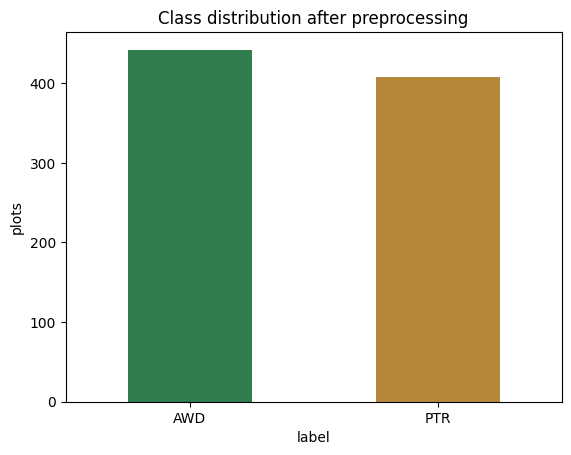

In [4]:
LABEL_MAP = {"AWD": 1, "PTR": 0}
RESEARCH_CLASSES = {"AWD", "PTR", "DSR"}
EXCLUDE = {"label", "class", "sn", "geometry", "latitude", "longitude", "lat", "lon", "lng", "district",
           "stratify_key", "planting_date", "field_id", "plot_id", "parcel_id", "farm_id", "id", "index",
           "awd", "irrigation", "target", "is_awd", "is_flooded", "drydown_event"}

def prepare_data(frame):
    """Same logic as Terra Audit's prepare_data() for data without plot IDs."""
    labels = frame["label"].astype("string").str.strip().str.upper()
    assert set(labels.dropna().unique()) <= RESEARCH_CLASSES
    valid = labels.isin(LABEL_MAP)
    y = labels.loc[valid].map(LABEL_MAP).astype(int).reset_index(drop=True)
    df = frame.loc[valid].reset_index(drop=True)
    features = [c for c in df.columns
                if c.lower().strip() not in EXCLUDE
                and not any(t in c.lower() for t in ("latitude", "longitude", "target", "label", "ground_truth"))
                and pd.api.types.is_numeric_dtype(df[c])]
    X = df[features].replace([np.inf, -np.inf], np.nan)
    keep = ~X.duplicated()
    return X.loc[keep].reset_index(drop=True), y.loc[keep].reset_index(drop=True), int(valid.sum())

X, y, rows_awd_ptr = prepare_data(raw)
print(f"AWD + PTR rows: {rows_awd_ptr}; duplicate rows removed: {rows_awd_ptr - len(X)}; rows used: {len(X)}")
counts = y.map({1: "AWD", 0: "PTR"}).value_counts()
print(counts.to_dict(), f"-> AWD share {y.mean():.1%} (balanced; no resampling needed)")
counts.plot.bar(color=["#2f7d4f", "#b5873a"], title="Class distribution after preprocessing", rot=0)
plt.ylabel("plots"); plt.show()


## 5. Features (as used in the project)

The model uses the **61 handcrafted (HC) features** published by the research, computed from each plot's
**ascending-orbit Sentinel-1** radar backscatter (VV, VH and the VV/VH ratio) between **June 1 and September 5**:

* a smooth daily curve (cubic spline) is fitted to each signal;
* features describe that curve: its first three **troughs** and **crests** (value and day), how many there are,
  **inflection points**, **min / max / mean / std**, and a **Gaussian fit** to the VV/VH ratio.

In the live app, Terra Audit computes these same 61 features from Google Earth Engine for a real field
(`src/ai/ml/ricemapper_features.py`). That code was checked against the original research functions on real
Sentinel-1 data and produced **identical values (difference 0.0)**.

**Feature selection:** none is applied. In Terra Audit's nested cross-validation, dropping features or keeping
only the most important half did **not** improve accuracy, so all 61 features are kept.
The cell below rebuilds the expected feature names (same rule as the project's `feature_names()`) and checks
the dataset matches them exactly.


In [5]:
ORBIT = "ASCENDING"
VARIABLES = [f"VV_{ORBIT}_mean_spline", f"VH_{ORBIT}_mean_spline", f"{ORBIT}_spline_ratio"]

def feature_names(k=3):
    names = [f"{ORBIT}_ratio_gaussian_{p}" for p in ("a", "b", "c", "r2")]
    for var in VARIABLES:
        for base in ("troughs_values", "crests_values", "trough_days", "crest_days"):
            names += [f"{var}_{base}_{i + 1}" for i in range(k)]
        names += [f"{var}_num_troughs", f"{var}_num_crests"]
    for var in VARIABLES:
        names += [f"{s}_{var}" for s in ("inflection_points", "min", "max", "mean", "std")]
    return names

assert set(X.columns) == set(feature_names()), "Dataset features differ from Terra Audit's inference features"
print(f"{X.shape[1]} features - identical to the features Terra Audit computes at inference.")

groups = pd.Series({c: ("Gaussian fit" if "gaussian" in c else "Trough/crest" if any(t in c for t in
                    ("trough", "crest")) else "Summary statistic") for c in X.columns})
print(groups.value_counts().to_dict())
print("Missing values per column (filled with the training median inside the pipeline):")
print(X.isna().sum()[lambda s: s > 0].to_dict())


61 features - identical to the features Terra Audit computes at inference.
{'Trough/crest': 42, 'Summary statistic': 15, 'Gaussian fit': 4}
Missing values per column (filled with the training median inside the pipeline):
{'ASCENDING_ratio_gaussian_a': 1, 'ASCENDING_ratio_gaussian_b': 1, 'ASCENDING_ratio_gaussian_c': 1, 'ASCENDING_ratio_gaussian_r2': 1}


## 6. Train/test split and the Random Forest

* **Split:** 80% training / 20% held-out test, **stratified** (same AWD/PTR ratio in both parts), `random_state = 42`.
  The test rows are never used for training or tuning.
* **Pipeline:** missing values are filled with the **median of the training rows only** (done inside the
  pipeline, so test data never influences preprocessing), then a Random Forest:
  250 trees, `min_samples_leaf = 2`, `class_weight = "balanced"`, `random_state = 42`.

A Random Forest is many decision trees, each trained on a random sample of rows and features; the
prediction is the trees' majority vote. It needs no feature scaling and handles non-linear patterns.


In [6]:
def make_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("classifier", RandomForestClassifier(n_estimators=250, min_samples_leaf=2,
                                              class_weight="balanced", random_state=SEED, n_jobs=-1)),
    ])

train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=TEST_FRACTION,
                                       stratify=y, random_state=SEED)
assert set(train_idx).isdisjoint(test_idx)
X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

model = make_model()
model.fit(X_train, y_train)
print(f"Train rows: {len(train_idx)} | held-out test rows: {len(test_idx)}")
print(f"Accuracy on its own training rows: {model.score(X_train, y_train):.3f} (a forest memorises training data)")


Train rows: 680 | held-out test rows: 170
Accuracy on its own training rows: 1.000 (a forest memorises training data)


## 7. Repeated stratified cross-validation

One 80/20 split of ~850 rows is noisy: a lucky or unlucky split can move accuracy by several points.
**Repeated stratified 5-fold cross-validation** trains and tests a fresh copy of the model 25 times
(5 folds × 5 repeats, seed 42) over the whole dataset and reports the **average and spread**.
This is the most honest single number for how well the model generalises.


Repeated 5x5 CV accuracy: 0.607 +/- 0.043  (min 0.529, max 0.700)
Repeated 5x5 CV ROC-AUC : 0.652 +/- 0.048
Training accuracy inside CV: 1.000  -> large gap = overfitting to training rows
Chance level (always guess the larger class): 0.520


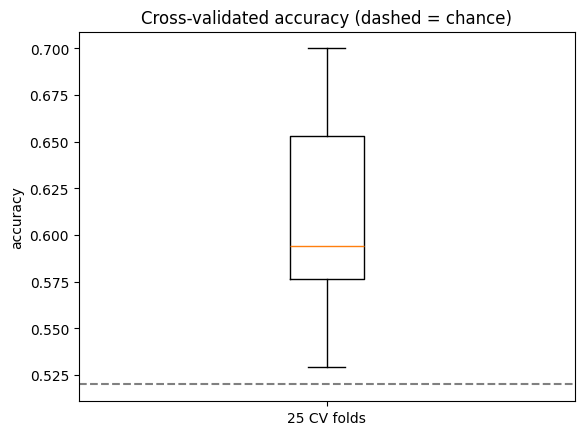

In [7]:
cv = cross_validate(clone(make_model()), X, y, scoring=["accuracy", "roc_auc"],
                    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED),
                    return_train_score=True)
cv_acc, cv_auc = cv["test_accuracy"], cv["test_roc_auc"]
print(f"Repeated 5x5 CV accuracy: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}  (min {cv_acc.min():.3f}, max {cv_acc.max():.3f})")
print(f"Repeated 5x5 CV ROC-AUC : {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"Training accuracy inside CV: {cv['train_accuracy'].mean():.3f}  -> large gap = overfitting to training rows")
print(f"Chance level (always guess the larger class): {max(y.mean(), 1 - y.mean()):.3f}")
plt.boxplot([cv_acc], tick_labels=["25 CV folds"]); plt.axhline(max(y.mean(), 1 - y.mean()), ls="--", c="grey")
plt.title("Cross-validated accuracy (dashed = chance)"); plt.ylabel("accuracy"); plt.show()


## 8. Held-out test evaluation

Now the trained model predicts the 170 test rows it has never seen.
The **AWD score** is the share of trees voting AWD (0–1). It is **not calibrated**, so 0.6 should not be read
as "60% probability".


In [8]:
y_pred = model.predict(X_test)
awd_score = model.predict_proba(X_test)[:, 1]
test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, awd_score),
    "brier_score": brier_score_loss(y_test, awd_score),
}
for name, value in test_metrics.items():
    print(f"{name:>18}: {value:.4f}")


          accuracy: 0.6647
 balanced_accuracy: 0.6637
           roc_auc: 0.7190
       brier_score: 0.2161


## 9. Confusion matrix

Rows are the **true** labels, columns the **predicted** labels. The diagonal counts correct predictions;
off-diagonal cells are the mistakes (PTR plots called AWD, and AWD plots called PTR).


[[52 30]
 [27 61]]


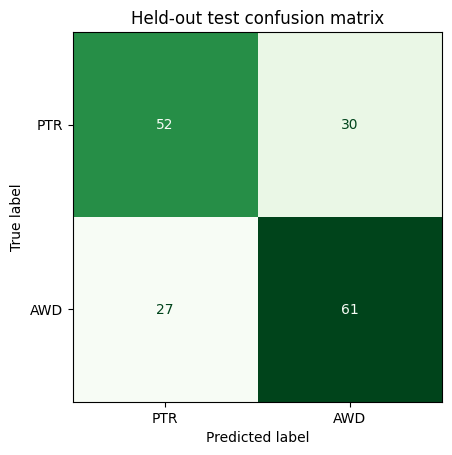

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)
ConfusionMatrixDisplay(cm, display_labels=["PTR", "AWD"]).plot(cmap="Greens", colorbar=False)
plt.title("Held-out test confusion matrix"); plt.show()


## 10. Precision, recall, F1-score and accuracy

* **Precision** — of the plots predicted AWD, how many really were AWD.
* **Recall** — of the real AWD plots, how many the model found.
* **F1-score** — the balance (harmonic mean) of precision and recall.
* **Accuracy** — share of all test plots predicted correctly.


In [10]:
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=["PTR", "AWD"], digits=3))
p, r, f, s = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1], zero_division=0)
pd.DataFrame({"precision": p, "recall": r, "f1": f, "test rows": s}, index=["PTR", "AWD"]).round(3)


              precision    recall  f1-score   support

         PTR      0.658     0.634     0.646        82
         AWD      0.670     0.693     0.682        88

    accuracy                          0.665       170
   macro avg      0.664     0.664     0.664       170
weighted avg      0.664     0.665     0.664       170



,precision,recall,f1,test rows
PTR,0.658,0.634,0.646,82
AWD,0.670,0.693,0.682,88


## 11. Feature importance

Two views of which features the forest relies on:

* **Impurity importance** (built into the forest; fast, but can favour features with many distinct values).
* **Permutation importance** on the held-out test set: shuffle one feature and measure how much accuracy
  drops. A drop near zero means the model barely uses that feature.

With weak signal overall, importances are small and spread across many features — consistent with the
modest accuracy.


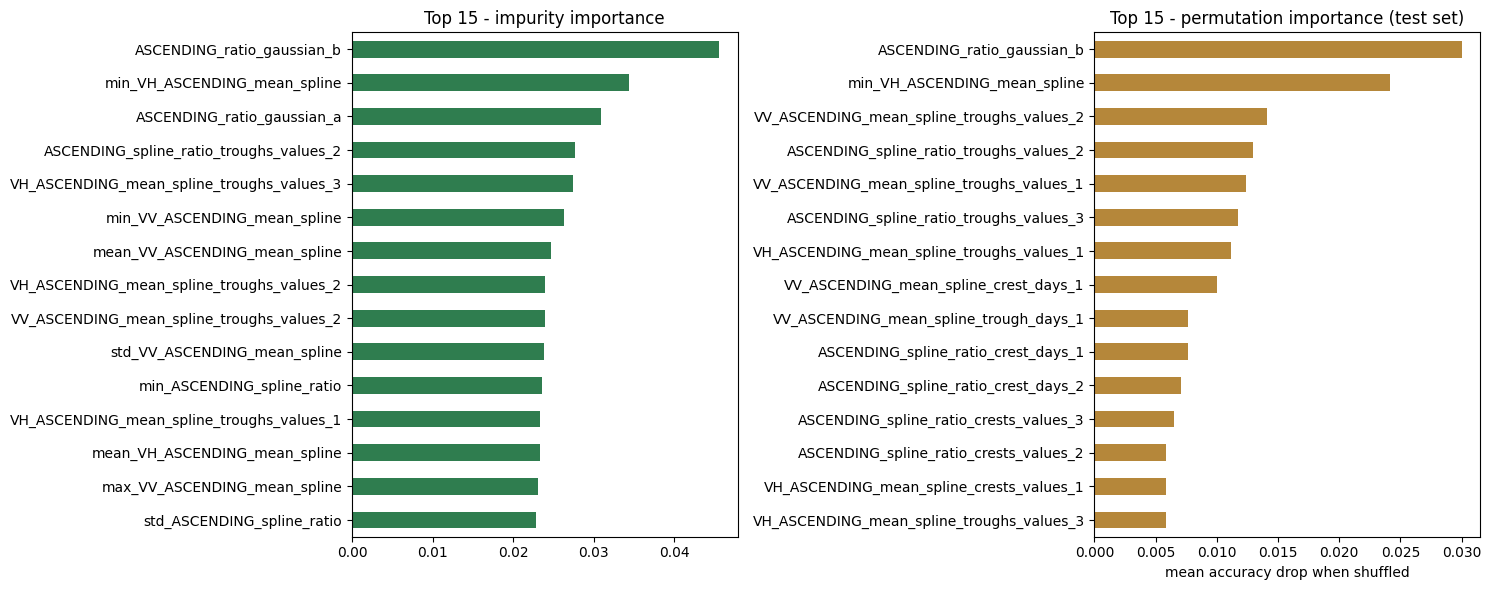

In [11]:
forest = model.named_steps["classifier"]
impurity = pd.Series(forest.feature_importances_, index=X.columns).sort_values().tail(15)
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=SEED, n_jobs=-1)
permuted = pd.Series(perm.importances_mean, index=X.columns).sort_values().tail(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
impurity.plot.barh(ax=axes[0], color="#2f7d4f", title="Top 15 - impurity importance")
permuted.plot.barh(ax=axes[1], color="#b5873a", title="Top 15 - permutation importance (test set)")
axes[1].set_xlabel("mean accuracy drop when shuffled")
plt.tight_layout(); plt.show()


## 12. Predicting an example research-data sample

We take the **first row of the held-out test set** (never seen in training), show a few of its features,
and ask the model for a prediction. In the Terra Audit app the same step runs on features computed from a
real field's Sentinel-1 data.


In [12]:
sample = X_test.iloc[[0]]
true_label = "AWD" if y_test.iloc[0] == 1 else "PTR"
score = model.predict_proba(sample)[0, 1]
print(sample[["min_VH_ASCENDING_mean_spline", "max_VH_ASCENDING_mean_spline",
              "VV_ASCENDING_mean_spline_num_troughs", "ASCENDING_ratio_gaussian_r2"]].T)
print(f"\nPrediction: {'AWD-like' if score >= 0.5 else 'PTR-like'} (AWD score {score:.3f}, uncalibrated)")
print(f"True research label: {true_label}")
print("Reminder: this is a practice-level label, not a count of AWD drying events.")


                                            21
min_VH_ASCENDING_mean_spline          0.006491
max_VH_ASCENDING_mean_spline          0.074261
VV_ASCENDING_mean_spline_num_troughs  2.000000
ASCENDING_ratio_gaussian_r2           0.993118

Prediction: PTR-like (AWD score 0.392, uncalibrated)
True research label: PTR
Reminder: this is a practice-level label, not a count of AWD drying events.


## 13. Comparison with the deployed model's recorded metrics

The values below are copied from Terra Audit's
`src/ai/ml/artifacts/ricemapper_awd/metrics.json` (written when the deployed model was trained).
With the same data, seeds, settings and scikit-learn 1.9.1, the notebook should reproduce them exactly.


In [13]:
deployed = {  # from src/ai/ml/artifacts/ricemapper_awd/metrics.json
    "rows (AWD+PTR)": 863, "duplicates removed": 13, "train rows": 680, "test rows": 170,
    "test accuracy": 0.6647058823529411, "test balanced accuracy": 0.6636640798226164,
    "test ROC-AUC": 0.7189578713968958, "test Brier score": 0.21613121124145954,
    "AWD precision": 0.6703296703296703, "AWD recall": 0.6931818181818182, "AWD F1": 0.6815642458100558,
    "PTR precision": 0.6582278481012658, "PTR recall": 0.6341463414634146, "PTR F1": 0.6459627329192547,
    "repeated CV accuracy (mean)": 0.6068235294117647, "repeated CV accuracy (std)": 0.0427976651046328,
    "repeated CV ROC-AUC (mean)": 0.6520223100497377, "repeated CV ROC-AUC (std)": 0.048251533350229636,
}
deployed_cm = [[52, 30], [27, 61]]
notebook = {
    "rows (AWD+PTR)": rows_awd_ptr, "duplicates removed": rows_awd_ptr - len(X),
    "train rows": len(train_idx), "test rows": len(test_idx),
    "test accuracy": test_metrics["accuracy"], "test balanced accuracy": test_metrics["balanced_accuracy"],
    "test ROC-AUC": test_metrics["roc_auc"], "test Brier score": test_metrics["brier_score"],
    "AWD precision": p[1], "AWD recall": r[1], "AWD F1": f[1],
    "PTR precision": p[0], "PTR recall": r[0], "PTR F1": f[0],
    "repeated CV accuracy (mean)": cv_acc.mean(), "repeated CV accuracy (std)": cv_acc.std(),
    "repeated CV ROC-AUC (mean)": cv_auc.mean(), "repeated CV ROC-AUC (std)": cv_auc.std(),
}
comparison = pd.DataFrame({"notebook": notebook, "deployed model": deployed})
comparison["difference"] = comparison["notebook"] - comparison["deployed model"]
# ROC-AUC and Brier use the averaged tree probabilities; with n_jobs=-1 the forest adds them up in
# parallel, so the summation order (and the last few decimals) can vary between runs.
probability_based = ["test ROC-AUC", "test Brier score", "repeated CV ROC-AUC (mean)", "repeated CV ROC-AUC (std)"]
exact = comparison.drop(index=probability_based)
print("Confusion matrix identical:", cm.tolist() == deployed_cm)
print("Counts, accuracy, precision, recall, F1 identical:", bool((exact["difference"].abs() < 1e-12).all()))
print("ROC-AUC / Brier within 0.0001:", bool((comparison.loc[probability_based, "difference"].abs() < 1e-4).all()),
      f"(largest difference {comparison.loc[probability_based, 'difference'].abs().max():.1e})")
with pd.option_context("display.float_format", "{:.6f}".format):
    display(comparison)


Confusion matrix identical: True
Counts, accuracy, precision, recall, F1 identical: True
ROC-AUC / Brier within 0.0001: True (largest difference 2.6e-06)


,notebook,deployed model,difference
rows (AWD+PTR),863.000000,863.000000,0.000000
duplicates removed,13.000000,13.000000,0.000000
train rows,680.000000,680.000000,0.000000
test rows,170.000000,170.000000,0.000000
test accuracy,0.664706,0.664706,0.000000
test balanced accuracy,0.663664,0.663664,0.000000
test ROC-AUC,0.718958,0.718958,0.000000
test Brier score,0.216131,0.216131,0.000000
AWD precision,0.670330,0.670330,0.000000
AWD recall,0.693182,0.693182,0.000000


**Explaining any differences**

* With **scikit-learn 1.9.1**, the same seeds and the same file (checksum-verified), the split, the confusion
  matrix, accuracy, balanced accuracy, precision, recall, F1 and the repeated-CV accuracy match the deployed
  model **exactly**.
* **ROC-AUC and the Brier score can differ in about the 5th decimal place.** They are computed from the
  forest's averaged probabilities, and with `n_jobs=-1` (the deployed setting) the trees' probabilities are
  added up in parallel, so the summation order varies slightly between runs. This was measured: two identical
  runs gave CV ROC-AUC 0.6520306 and 0.6520223, while accuracy was identical to 10 decimals. With `n_jobs=1`
  the results are fully deterministic. The deployed model's own recorded values fall inside this tiny range.
* If Colab cannot install 1.9.1 (a warning prints in section 2), tree-building details can change between
  scikit-learn versions, giving small differences (typically within a point or two of accuracy).
  The **repeated CV mean** is the most stable figure to compare.
* The **held-out test accuracy (≈66%) is higher than the repeated-CV accuracy (≈61%)**. That is not an error:
  one 170-row split happens to be on the lucky side; the 25-fold average is the more reliable estimate.


## 14. Why the June 1 – September 5 window? (reproducible evidence)

The research published two AWD date windows. With the same final model settings and the same 5×5 repeated CV,
the June–September window scores higher, so Terra Audit uses it. (Terra Audit's nested cross-validation also
found that hyperparameter tuning and feature selection gave no real gain, so the simple settings were kept.)


In [14]:
X_alt, y_alt, _ = prepare_data(pd.read_parquet(data_dir / ALT_FILE))
cv_alt = cross_validate(clone(make_model()), X_alt, y_alt, scoring="accuracy",
                        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED))["test_score"]
print(f"May 1 - Dec 15 window: {cv_alt.mean():.3f} +/- {cv_alt.std():.3f}")
print(f"Jun 1 - Sep 5 window : {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}  <- used by Terra Audit")


May 1 - Dec 15 window: 0.582 +/- 0.033
Jun 1 - Sep 5 window : 0.607 +/- 0.043  <- used by Terra Audit


## 15. Summary and limitations (for the viva)

**What was shown**

* A Random Forest trained on **real, independently labelled research data** (not synthetic, not pre-trained).
* Leakage controls: DSR excluded per the research task, duplicates removed before splitting, stratified
  held-out test set, preprocessing fitted inside the pipeline, fixed seeds.
* Honest performance: **≈61% repeated-CV accuracy** (chance ≈52%) and ≈66% on one held-out split —
  a weak but real signal.

**Limitations**

1. **Practice label, not cycle count:** AWD-like vs PTR-like for a season; it does not count drying events,
   so it cannot verify VM0051's water-regime factor on its own.
2. **No measured CF labels:** PTR is a sowing method used as the conventional comparison.
3. **Different region:** Punjab, India (Kharif 2024); accuracy on Bangladesh fields is unknown, and Bangladesh's
   Boro season (Jan–May) falls outside the June–September window.
4. **No plot IDs:** the split is by row, so related plots could sit on both sides; scores may be slightly optimistic.
5. **Weak features:** the training rows are memorised (≈100% training accuracy) while generalisation is ≈61%.
6. **Inference preprocessing differs slightly:** the app uses Google Earth Engine gamma0 without the research's
   SNAP speckle filter.
7. **Uncalibrated score:** the AWD score is a vote share, not a probability.

Terra Audit therefore shows this model only as an **experimental, read-only comparison**; it never changes
drydown counting, carbon calculations, readiness or credit issuance.
